In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Experiment: EfficientNetV2B2 + Triplet Loss - 100 Authors

Author identification experiment on handwritten documents using **Siamese Networks with Triplet Loss**.

**Objetive**: learn dn embedding space where patches from the same author cluster together and patches from different authors are pushed apart, enabling identification by similarity.

**Experiment setup**:
- Dataset: variant 4 (lines removed, grayscale)
- Authors: 100 (range=(0, 100))
- Architecture: EfficientNetV2B2 fine-tuned + embedding head + triplet siamese network.

In [2]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
)
import seaborn as sns
import cv2
import yaml

In [3]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 106.3 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=e11b4589249db58384b686a110d57299f552770018543471b17157c0153d0aee
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


## Configuration

Configuration is split into dataclasses by domain of responsibility:

- ModelConfig - siamese network type (pair o triplet)
- `DataConfig` - selected authors and image shapes
- TrainingConfig - training hyperparameters
- BatchConfig - batch sizes per split

**Key decisions**:
- val_ratio=0.25 - fraction on non-test data reserved for validation
- epochs=30 - maximum training epochs (early stopping may trigger earlier)

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
def load_config(path: str) -> Config:
  with open(path, "r") as f:
      cfg_dict = yaml.safe_load(f)

  authors_cfg = cfg_dict["data"]["authors_range"]

  return Config(
        project_path=cfg_dict["project_path"],
        dataset=cfg_dict["dataset"],
        model=ModelConfig(**cfg_dict["model"]),
        data=DataConfig(
            authors_range=range(authors_cfg["start"], authors_cfg["end"]),
            original_shape=tuple(cfg_dict["data"]["original_shape"]),
            model_input_shape=tuple(cfg_dict["data"]["model_input_shape"]),
        ),
        training=TrainingConfig(**cfg_dict["training"]),
        batch=BatchConfig(**cfg_dict["batch"]),
        current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S"),
    )

In [6]:
config = load_config(path="drive/MyDrive/author-handwriting-recog/config/test_100_4.yaml")

In [7]:
def display_output(path: str):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    plt.figure(figsize=(w/100, h/100), dpi=100)
    plt.imshow(img, interpolation='nearest')
    plt.axis("off")
    plt.show()

In [8]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [9]:
def upload_file_to_source(source_file: str, dest_folder: str):
    os.makedirs(dest_folder, exist_ok=True)

    shutil.copy2(source_file, dest_folder)

In [10]:
upload_source(
    source=f"{config.project_path}/src",
    source_dest="./src"
)

In [11]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/180_360_90/{config.dataset}.tar.gz",
    dest_folder=f"./dataset"
)

In [ ]:
upload_file_to_source(
    source_file=f"{config.project_path}/data/datasets/experiments/efficientnet_100/siamese_model_100_20260407-134904.keras",
    dest_folder="./models"
)

In [101]:
upload_source(
    source=f"{config.project_path}/data/datasets/experiments/efficientnet_100/outputs",
    source_dest="./outputs"
)

In [12]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [13]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [14]:
from src.models import (
    EfficientNetV2Backbone,
    TripletLoss,
    EmbeddingNetwork,
    SiameseFactory
)
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
    BaseMetricTrainer,
)
from src.evaluator import (
    TripletEvaluator,
    EmbeddingEvaluator,
    EmbeddingVisualizer,
)

In [15]:
from src.evaluator.embedding_utils import EmbeddingExtractor, UMAPReducer
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)

In [16]:
logger = LoggerFactory.get_logger(
    "efficient_test_100_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"efficient_triplet_{config.current_time}"
)

In [17]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [18]:
!tar -xzf {dataset_path} -C ./

## Dataset

The dataset is stored in .zarr format with spatial separation between train and test:

```
dataset.zarr
├── non_test/   ← patches from the main writing area (train + val)
└── test/       ← patches from the test area, physically separated in the original image
```

`SelectiveDataLoader` selects a subset of authors and builds the three splits (train, val, test) guaranteeing that **no patch from the test area appears in train o val**.
This eliminates data leakage by spatial position.

In [19]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [20]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

13:52:47 - efficient_test_100_4 - INFO - Total patches selected: 63969
13:52:47 - efficient_test_100_4 - INFO - Train: 47976 | Val: 15993 | Test: 4372
13:52:47 - efficient_test_100_4 - INFO - Avg non_test patches per author: 639.69 | Min: 399 | Max: 883
13:52:47 - efficient_test_100_4 - INFO - Avg test patches per author: 43.72 | Min: 34 | Max: 49
13:52:47 - efficient_test_100_4 - INFO - Image shape: (180, 360)
13:52:47 - efficient_test_100_4 - INFO - Zarr chunk shape: (64, 180, 360)


## Augmentation

Two distinct pipelines are used:

- **pipeline_train** - full augmentation: rotation, zoom, shift, noise, brightness, contrast
- **pipeline** - resize _ normalization only (no perturbations)

The training pipeline introduces artificial variability to improve generaliaztion. The validation/test pipeline is deterministic for reproducible evaluation.

> efficientnet_preprocess at the end is required - it normalizes pixel values to the range expected by EfficientNetV2 (ImageNet statistics)

In [21]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.efficientnet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.efficientnet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [22]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [23]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [24]:
display_generator_info(train_triplet)

13:52:59 - efficient_test_100_4 - INFO - Generator: TripletGenerator
13:52:59 - efficient_test_100_4 - INFO - Number of samples: 47976
13:52:59 - efficient_test_100_4 - INFO - Batch size: 32
13:52:59 - efficient_test_100_4 - INFO - Steps per epoch: 1500
13:52:59 - efficient_test_100_4 - INFO - Shape: (180, 360)
13:52:59 - efficient_test_100_4 - INFO - Number of authors: 100


In [25]:
display_generator_info(val_triplet)

13:53:01 - efficient_test_100_4 - INFO - Generator: TripletGenerator
13:53:01 - efficient_test_100_4 - INFO - Number of samples: 15993
13:53:01 - efficient_test_100_4 - INFO - Batch size: 16
13:53:01 - efficient_test_100_4 - INFO - Steps per epoch: 1000
13:53:01 - efficient_test_100_4 - INFO - Shape: (180, 360)
13:53:01 - efficient_test_100_4 - INFO - Number of authors: 100


In [26]:
display_generator_info(test_triplet)

13:53:05 - efficient_test_100_4 - INFO - Generator: TripletGenerator
13:53:05 - efficient_test_100_4 - INFO - Number of samples: 4372
13:53:05 - efficient_test_100_4 - INFO - Batch size: 8
13:53:05 - efficient_test_100_4 - INFO - Steps per epoch: 547
13:53:05 - efficient_test_100_4 - INFO - Shape: (180, 360)
13:53:05 - efficient_test_100_4 - INFO - Number of authors: 100


## Model Construction

The architecture follows a chain of separated responsibilities:

```
EfficientNetV2Backbone      → extracts visual features (pre-trained on ImageNet)
    ↓
EmbeddingNetwork            → projects features to an L2-normalized embedding space
    ↓
SiameseFactory              → builds the triplet siamese network (anchor, positive, negative)
    ↓
ModelTrainerFactory         → wraps the network in a trainer with training/eval logic
```

**`trainer.siamese_network`** — full triplet network, used during training.
**`trainer.embedding_model`** — backbone + embedding head, used to extract embeddings at evaluation time.
Both share the same weights in memory.

In [27]:
embedding_network = EmbeddingNetwork(
    backbone=EfficientNetV2Backbone(variant="B2", freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
)

In [28]:
siamese_builder = SiameseFactory.create(
    model_type=config.model.type,
    embedding_network=embedding_network,
    input_shape=config.data.model_input_shape,
)

In [29]:
trainer = ModelTrainerFactory.create(
    siamese_builder=siamese_builder,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [30]:
trainer.initialize_model()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


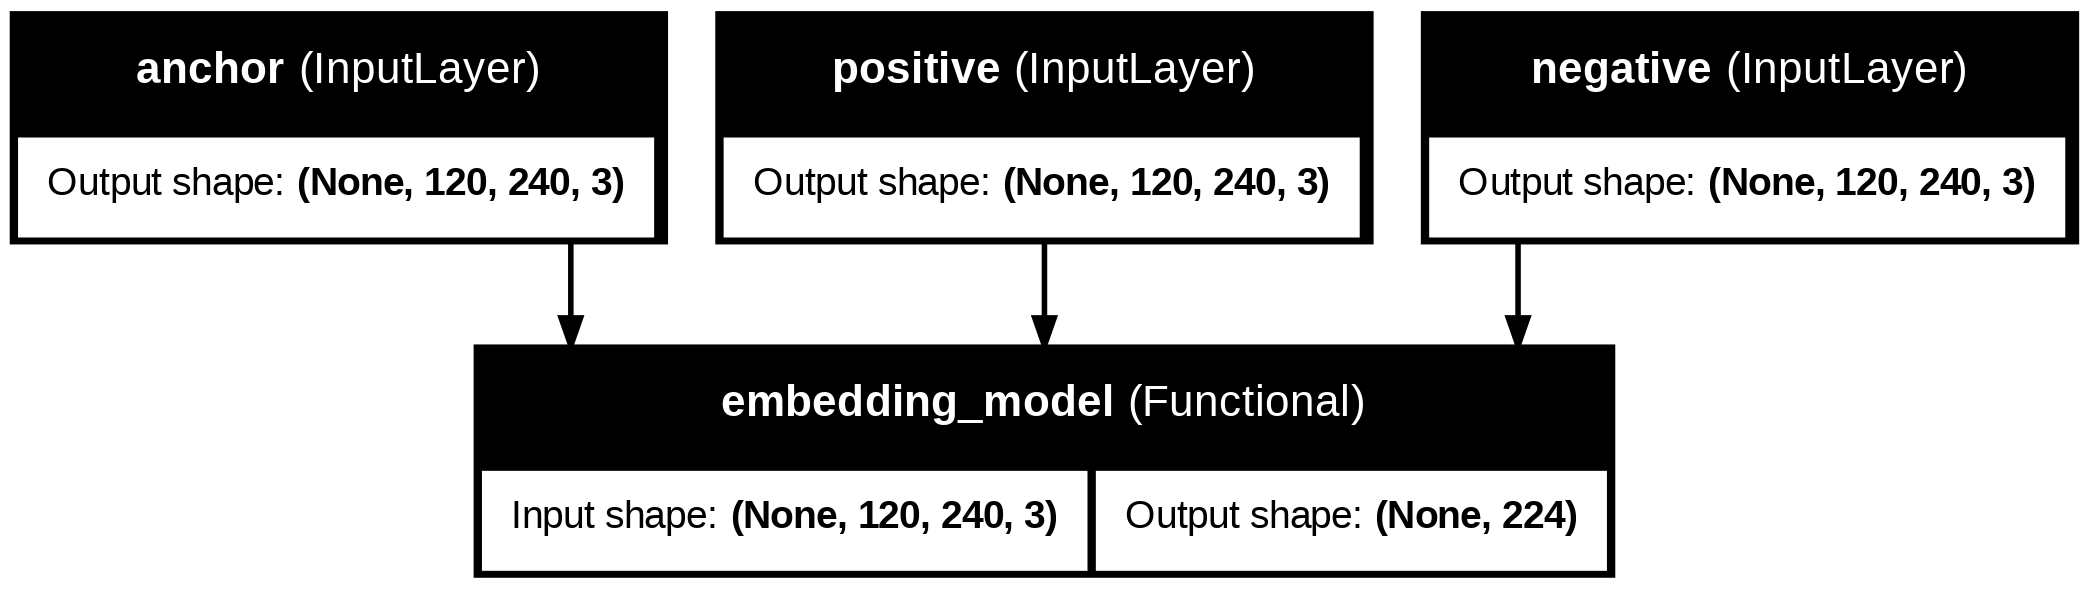

In [31]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [32]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  9,503,870 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,503,870 (36.25 MB)

 Trainable params: 8,699,340 (33.19 MB)

 Non-trainable params: 804,530 (3.07 MB)

In [33]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b2 (Functional)  │ (None, 4, 8, 1408)     │     8,769,374 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 448)            │       631,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,503,870 (36.25 MB)

 Trainable params: 8,699,340 (33.19 MB)

 Non-trainable params: 804,530 (3.07 MB)

## Compilation and Training

**TripletLoss** with margin=0.4:
minimizes max(d(a, p) - d(a, n) + margin, 0) where d is cosine distance.

**Monirored metrics**:
- ap_sim - average cosine similarity between anchor and positive (want: high)
- an_sim - average cosine similarity between anchor and negative (want: low)
- margin - difference ap_sim - an_sim (want: positive and increasin)
- triplet_acc - fraction of triplets where ap_sim > an_sim

**Callbacks**:
- EarlyStopping(patience=4) - stops training if vall_loss does not improve
- ReduceLROPlateau(patience=2) - reduces learning rate on plateau
- start_from_epoch=5 - early stopping is inactive during warm-up epochs

In [34]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [35]:
callbacks = get_default_callbacks(
    model_name="efficient_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [36]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - an_sim: -7.0204e-04 - ap_sim: 0.0368 - loss: 0.3640 - margin: 0.0375 - triplet_acc: 0.5919
Epoch 1: val_loss improved from None to 0.26453, saving model to checkpoints/efficient_siamese_triplet/best.weights.h5

Epoch 1: finished saving model to checkpoints/efficient_siamese_triplet/best.weights.h5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 555s 252ms/step - an_sim: -0.0012 - ap_sim: 0.0675 - loss: 0.3389 - margin: 0.0687 - triplet_acc: 0.6300 - val_an_sim: 0.0263 - val_ap_sim: 0.2056 - val_loss: 0.2645 - val_margin: 0.1792 - val_triplet_acc: 0.7254 - learning_rate: 1.0000e-05
Epoch 2/30
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - an_sim: 0.0025 - ap_sim: 0.2091 - loss: 0.2573 - margin: 0.2066 - triplet_acc: 0.7262
Epoch 2: val_loss improved from 0.26453 to 0.20890, saving model to checkpoints/efficient_siamese_triplet/best.weights.h5

Epoch 2: finished saving model to checkpoints/efficient_siamese_triplet/best.weights.h5
1500/1500 ━━━━━━

In [37]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

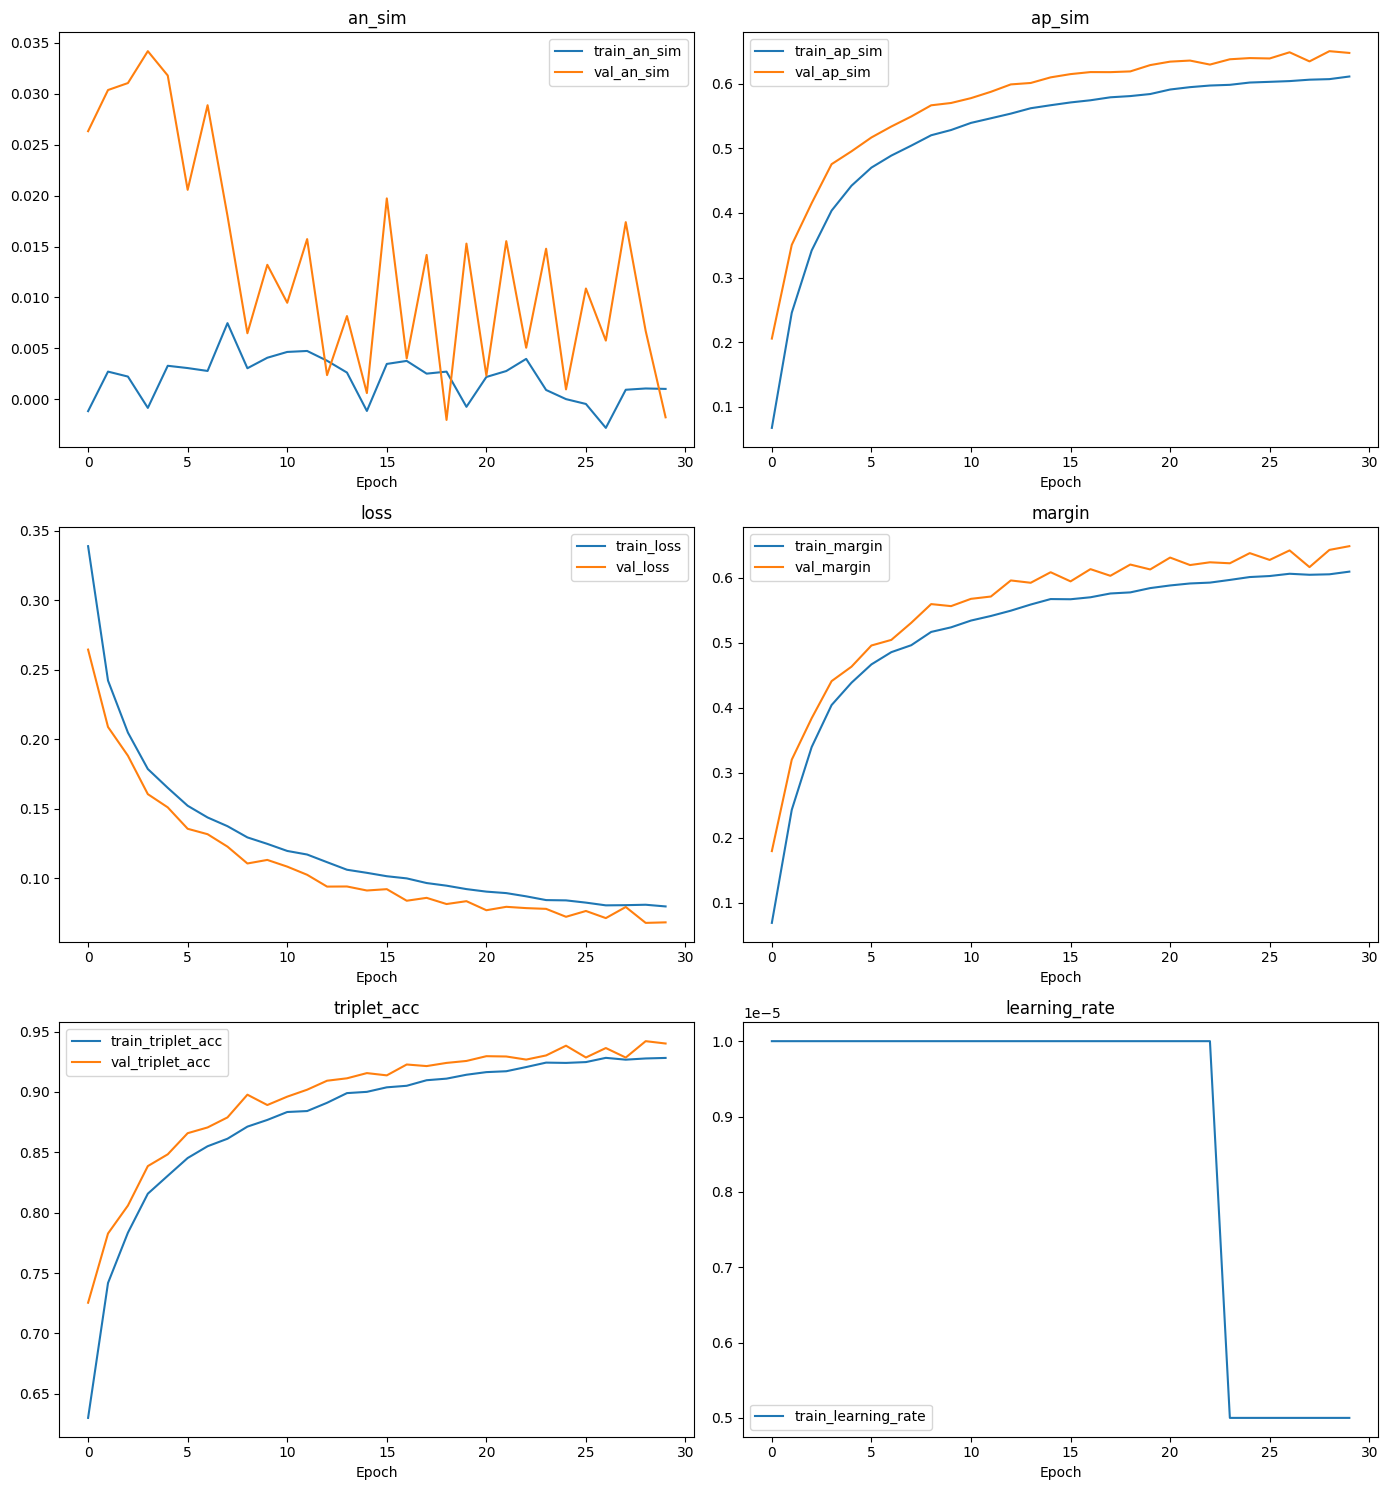

In [38]:
plot_keras_history(history)

In [39]:
def save_model(model: BaseMetricTrainer, path: str):
    model.siamese_network.save(f"{path}/siamese_model_100_{config.current_time}.keras")
    model.embedding_model.save(f"{path}/embedding_model_100_{config.current_time}.keras")

In [40]:
save_model(model=trainer, path="./models")

In [41]:
save_model(model=trainer, path=f"./{config.project_path}/data/datasets/experiments/efficientnet_100")

In [ ]:
trainer.siamese_network.load_weights("./models/siamese_model_100_20260407-134904.keras")

In [42]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_val, orient="index", columns=["value"])}")

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - an_sim: 0.0111 - ap_sim: 0.6494 - loss: 0.0718 - margin: 0.6383 - triplet_acc: 0.9366
16:06:57 - efficient_test_100_4 - INFO - 
                value
an_sim       0.011135
ap_sim       0.649401
loss         0.071791
margin       0.638266
triplet_acc  0.936597


In [43]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"\n{pd.DataFrame.from_dict(metrics_test, orient="index", columns=["value"])}")

547/547 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - an_sim: -0.0048 - ap_sim: 0.6948 - loss: 0.0556 - margin: 0.6996 - triplet_acc: 0.9524
16:07:50 - efficient_test_100_4 - INFO - 
                value
an_sim      -0.004759
ap_sim       0.694794
loss         0.055615
margin       0.699553
triplet_acc  0.952425


In [44]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [45]:
def display_heatmap(
    df: pd.DataFrame,
    title: str = "Confusion Matrix",
    show_accuracy: bool = True,
) -> None:
    """
    Display confusion matrix heatmap with optional accuracy in title.
    """

    if show_accuracy:
        correct = np.trace(df.values)
        total = df.values.sum()
        acc = correct / total if total > 0 else 0.0

        title = f"{title} (Acc={acc:.3f})"

    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title(title)

    plt.show()

## Triplet Evaluation

`TripletEvaluator` evaluates the model in terms of **pairwise similarity**:

- Generates triplets (anchor, positive, negative) from the test set
- Computes cosine similarity between anchor-positive and anchor-negative pairs
- **AUC** — ability to discriminate similar pairs from dissimilar ones
- **Triplet accuracy** — % of triplets where `sim(a,p) > sim(a,n)`

This evaluation measures the quality of the similarity space,
independently of the author identification strategy.

In [46]:
triplet_evaluator = TripletEvaluator(
    siamese_network=trainer.siamese_network,
    logger=logger,
)

In [47]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

16:08:08 - efficient_test_100_4 - INFO - === Triplet Evaluation Started ===
16:08:08 - efficient_test_100_4 - INFO - === Collecting triplet results ===
16:08:53 - efficient_test_100_4 - INFO - Total triplets collected: 547
16:08:53 - efficient_test_100_4 - INFO - [LOCAL] acc=0.9453 gap=0.6845 error=0.0547 auc=0.9518
16:08:53 - efficient_test_100_4 - INFO - === Computing global metrics ===
16:08:53 - efficient_test_100_4 - INFO - === Global metrics computed ===
16:08:53 - efficient_test_100_4 - INFO - === Triplet Evaluation Finished ===


In [48]:
logger.info(
    f"AUC: {triplet_report.local_metrics.auc:.4f}, "
    f"Accuracy: {triplet_report.local_metrics.triplet_accuracy:.4f}"
)

16:08:53 - efficient_test_100_4 - INFO - AUC: 0.9518, Accuracy: 0.9453


In [49]:
y_true = np.concatenate([
    np.ones(len(triplet_report.df_triplets)),
    np.zeros(len(triplet_report.df_triplets))
])
y_pred = np.concatenate([
    triplet_report.df_triplets["sim_ap"].values,
    triplet_report.df_triplets["sim_an"].values
])

### ROC Curve

The `ROC curve` evaluates the ability of the embedding space to distinguish between positive (same writer) and negative (different writer) pairs across all possible similarity thresholds.
The high `AUC` (≈0.94) indicates that the model learns a well-structured embedding space where genuine pairs are consistently assigned higher similarity scores than impostor pairs.

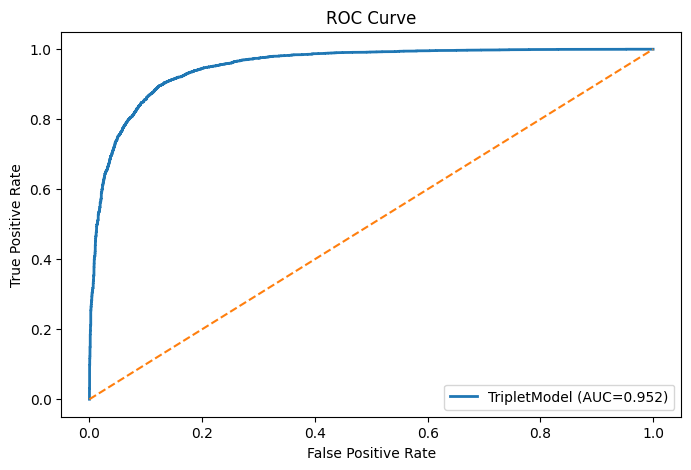

In [50]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, lw=2, label=f'TripletModel (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.show()

In [111]:
# EER: is a point where FPR ≈ FNR
fnr = 1 - tpr
eer_threshold = thresholds[np.argmin(np.abs(fpr - fnr))]
eer = fpr[np.argmin(np.abs(fpr - fnr))]
logger.info(f"EER: {eer:.4f} at threshold {eer_threshold:.4f}")

18:09:09 - efficient_test_100_4 - INFO - EER: 0.1162 at threshold 0.4294


### Precision-Recall Curve

The `precision-recall` analysis highlights the trade-off between correctly identifying matching pairs (recall) and avoiding false matches (precision).
As expected, lower thresholds increase recall but introduce more false positives, while higher thresholds improve precision at the cost of missing true matches.
This curve is useful for selecting an operating threshold depending on the application requirements.

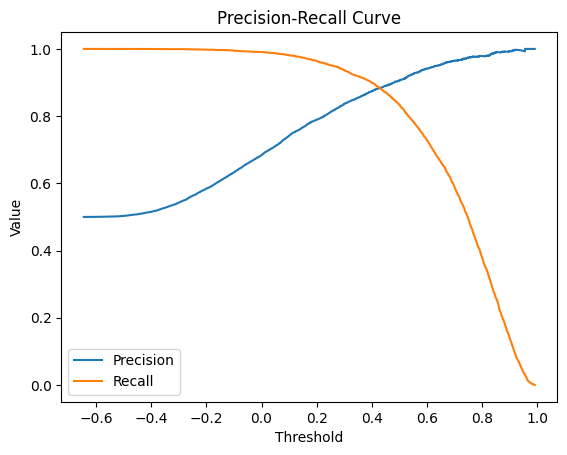

In [51]:
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred)

plt.figure()
plt.plot(thresholds_pr, precision[:-1], label='Precision')
plt.plot(thresholds_pr, recall[:-1], label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Value')
plt.title('Precision-Recall Curve')
plt.legend()

plt.show()

### Similarity Distribution

The similarity distribution plot shows the separation between positive pairs (same writer) and negative pairs (different writers) in the embedding space.
Positive pairs tend to have higher similarity values, while negative pairs are mostly concentrated in lower similarity regions.
This indicates that the model successfully learns a meaningful representation where samples from the same writer are closer in the feature space.

However, there is a noticeable overlap between the two distributions, particularly in the mid-range similarity values.
This overlap corresponds to ambiguous cases where the model struggles to distinguish between similar handwriting styles, leading to potential false positives and false negatives.

The degree of overlap explains why the model does not achieve perfect accuracy, despite the high AUC and triplet accuracy scores.
Reducing this overlap is key to further improving the model performance.

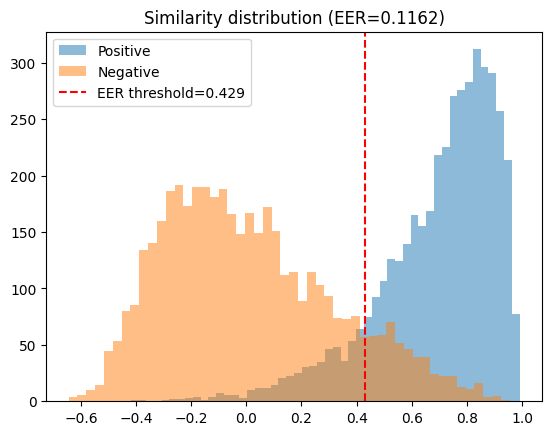

In [114]:
plt.hist(triplet_report.df_triplets["sim_ap"], bins=50, alpha=0.5, label="Positive")
plt.hist(triplet_report.df_triplets["sim_an"], bins=50, alpha=0.5, label="Negative")
plt.axvline(eer_threshold, linestyle='--', color='red', label=f"EER threshold={eer_threshold:.3f}")
plt.legend()
plt.title(f"Similarity distribution (EER={eer:.4f})")
plt.show()

### Confusion Matrix

The `confusion matrix` provides insight into which writers are more frequently confused by the model.
Strong diagonal values indicate correct identification, while off-diagonal entries reveal pairs of writers with similar handwriting characteristics.
This analysis helps identify systematic errors and potential limitations of the learned embedding space.

**Triplet-level Confusion Matrix**

The first confusion matrix is computed from individual triplet predictions.

Each decision is based on a local comparison between a positive and a negative sample.

This matrix reflects how often the model assigns the correct writer label in pairwise similarity decisions.

Due to the local nature of these comparisons, the matrix may contain noise and variability.

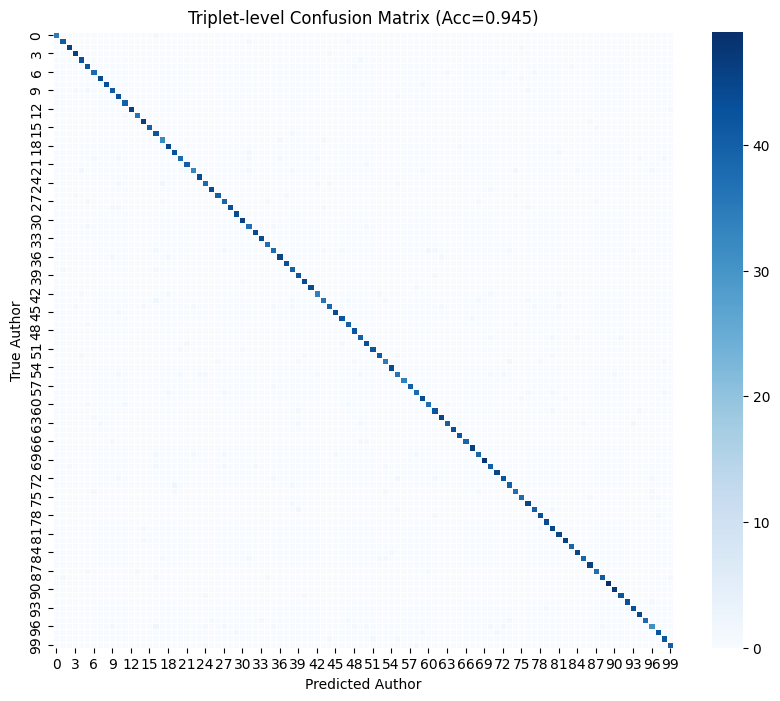

In [53]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Triplet-level Confusion Matrix")

**Author-level Confusion Matrix**

The second confusion matrix is derived from aggregated metrics across triplets.

For each writer, the model selects the most representative prediction based on a scoring function combining accuracy and similarity gap.

This results in a more stable and global evaluation of the model’s ability to distinguish between different writers.

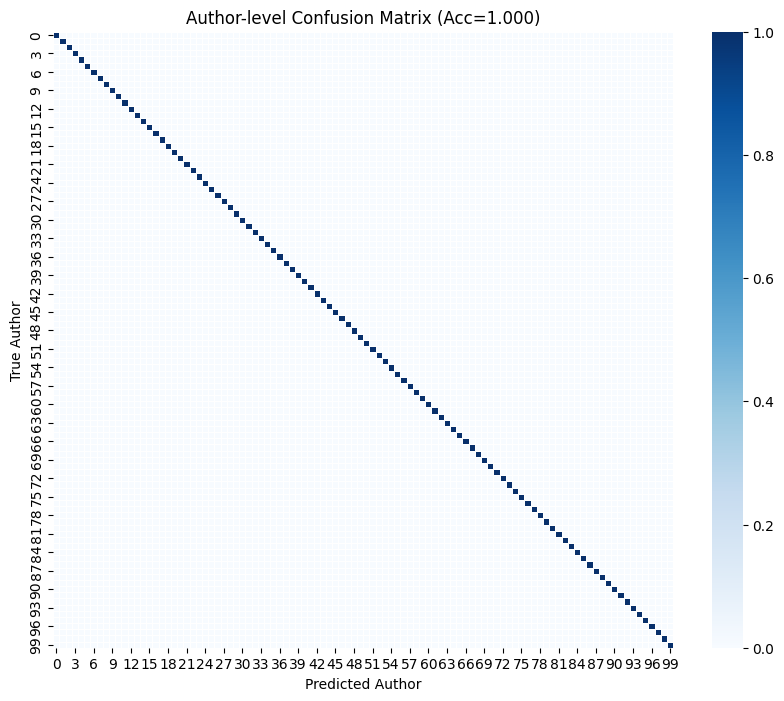

In [54]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix")

**Comparison**

While the triplet-level matrix evaluates local decision quality, the author-level matrix reflects global identification performance.

Together, they provide a comprehensive understanding of both the embedding quality and the consistency of writer discrimination.

In [55]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.914214,35,0.974222,0.974222
1,1,1,1.0,0.756755,41,0.898539,0.898539
2,2,2,1.0,0.843158,46,0.940069,0.940069
3,3,3,1.0,0.715733,46,0.878821,0.878821
4,4,4,1.0,0.680388,43,0.861832,0.861832
...,...,...,...,...,...,...,...
95,95,95,1.0,0.619991,38,0.832802,0.832802
96,96,96,1.0,0.527893,31,0.788535,0.788535
97,97,97,1.0,0.860681,42,0.948491,0.948491
98,98,98,1.0,0.858292,42,0.947343,0.947343


In [56]:
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [57]:
display_generator_info(val_gen)

16:10:01 - efficient_test_100_4 - INFO - Generator: DataGenerator
16:10:01 - efficient_test_100_4 - INFO - Number of samples: 15993
16:10:01 - efficient_test_100_4 - INFO - Batch size: 16
16:10:01 - efficient_test_100_4 - INFO - Steps per epoch: 1000
16:10:01 - efficient_test_100_4 - INFO - Shape: (180, 360)
16:10:01 - efficient_test_100_4 - INFO - Number of authors: 100


In [58]:
display_generator_info(test_gen)

16:10:03 - efficient_test_100_4 - INFO - Generator: DataGenerator
16:10:03 - efficient_test_100_4 - INFO - Number of samples: 4372
16:10:03 - efficient_test_100_4 - INFO - Batch size: 8
16:10:03 - efficient_test_100_4 - INFO - Steps per epoch: 547
16:10:03 - efficient_test_100_4 - INFO - Shape: (180, 360)
16:10:03 - efficient_test_100_4 - INFO - Number of authors: 100


## Embedding Evaluation

The main evaluation of the identification system.

**`EmbeddingExtractor`** uses `trainer.embedding_model` (not the full siamese network)
to extract one embedding per patch from the test set.

**Distance metrics:**
- `intra_distance` — average distance between patches from the **same** author
- `inter_distance` — average distance between patches from **different** authors
- A ratio `inter/intra >> 1` indicates good class separation in the embedding space

**Identification strategies:**
| Strategy | How it predicts the author of a patch |
|---|---|
| `1nn` | author of the nearest patch in the embedding space |
| `mean` | author whose mean embedding is most similar |
| `centroid` | author whose centroid (mean of train embeddings) is closest |
| `topk` | most frequent author among the K nearest neighbors |

**Aggregators — how predictions are aggregated at author level:**
| Aggregator | Logic |
|---|---|
| `patch` | accuracy per individual patch |
| `vote` | majority vote over all patches of the author |
| `score` | prediction by maximum average similarity |

> **The primary metric is `vote accuracy`.**
> Low patch accuracy (~60-80%) is expected and does not indicate model failure —
> an isolated patch can be ambiguous. Author identity emerges by aggregating
> evidence from multiple patches.

In [59]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [60]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [61]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [62]:
val_gen_results = emb_evaluator.evaluate(val_gen)

16:10:26 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Starting evaluation
16:10:26 - efficient_test_100_4 - INFO - Extracting embeddings from the model
16:10:26 - efficient_test_100_4 - INFO - Processing 1000 batches to extract embeddings
16:17:18 - efficient_test_100_4 - INFO - Extracted embeddings for 15993 samples
16:17:18 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(15993, 224)
16:17:18 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
16:17:18 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


16:17:51 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
16:17:51 - efficient_test_100_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
16:17:51 - efficient_test_100_4 - INFO - Applying strategy: 1nn
16:17:52 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:17:52 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:17:52 - efficient_test_100_4 - INFO - Applying aggregator: score
16:17:52 - efficient_test_100_4 - INFO - patch acc=0.5594Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
16:17:52 - efficient_test_100_4 - INFO - Applying strategy: mean
16:18:48 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:18:48 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:18:48 - efficient_test_100_4 - INFO - Applying aggregator: score
16:18:48 - efficient_test_100_4 - INFO - patch acc=0.4719Strategy 'mean' results: , vote acc=0.8200Strategy 'mean' results: , score acc

In [63]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

16:20:24 - efficient_test_100_4 - INFO - Intra distance: 0.33307933807373047
16:20:24 - efficient_test_100_4 - INFO - Inter distance: 0.9891001582145691
16:20:24 - efficient_test_100_4 - INFO - Strategy: 1nn
16:20:24 - efficient_test_100_4 - INFO - Patch accuracy: 0.5594
16:20:24 - efficient_test_100_4 - INFO - Vote accuracy: 1.0000
16:20:24 - efficient_test_100_4 - INFO - Score accuracy: 1.0000
16:20:24 - efficient_test_100_4 - INFO - ----------------------------------------
16:20:24 - efficient_test_100_4 - INFO - Strategy: mean
16:20:24 - efficient_test_100_4 - INFO - Patch accuracy: 0.4719
16:20:24 - efficient_test_100_4 - INFO - Vote accuracy: 0.8200
16:20:24 - efficient_test_100_4 - INFO - Score accuracy: 0.8200
16:20:24 - efficient_test_100_4 - INFO - ----------------------------------------
16:20:24 - efficient_test_100_4 - INFO - Strategy: centroid
16:20:24 - efficient_test_100_4 - INFO - Patch accuracy: 0.5257
16:20:24 - efficient_test_100_4 - INFO - Vote accuracy: 1.0000
16:

In [64]:
test_gen_results = emb_evaluator.evaluate(
    data_generator=test_gen,
    reducer=UMAPReducer(n_components=3),
)

16:20:24 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Starting evaluation
16:20:24 - efficient_test_100_4 - INFO - Extracting embeddings from the model
16:20:24 - efficient_test_100_4 - INFO - Processing 547 batches to extract embeddings
16:24:06 - efficient_test_100_4 - INFO - Extracted embeddings for 4372 samples
16:24:06 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(4372, 224)
16:24:06 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
16:24:06 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


16:24:13 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
16:24:13 - efficient_test_100_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
16:24:13 - efficient_test_100_4 - INFO - Applying strategy: 1nn
16:24:13 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:24:13 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:24:13 - efficient_test_100_4 - INFO - Applying aggregator: score
16:24:13 - efficient_test_100_4 - INFO - patch acc=0.8120Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
16:24:13 - efficient_test_100_4 - INFO - Applying strategy: mean
16:24:20 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:24:20 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:24:20 - efficient_test_100_4 - INFO - Applying aggregator: score
16:24:20 - efficient_test_100_4 - INFO - patch acc=0.5519Strategy 'mean' results: , vote acc=0.7800Strategy 'mean' results: , score acc

In [65]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

16:24:33 - efficient_test_100_4 - INFO - Intra distance: 0.2761602997779846
16:24:33 - efficient_test_100_4 - INFO - Inter distance: 1.002244472503662
16:24:33 - efficient_test_100_4 - INFO - Strategy: 1nn
16:24:33 - efficient_test_100_4 - INFO - Patch accuracy: 0.8120
16:24:33 - efficient_test_100_4 - INFO - Vote accuracy: 1.0000
16:24:33 - efficient_test_100_4 - INFO - Score accuracy: 1.0000
16:24:33 - efficient_test_100_4 - INFO - ----------------------------------------
16:24:33 - efficient_test_100_4 - INFO - Strategy: mean
16:24:33 - efficient_test_100_4 - INFO - Patch accuracy: 0.5519
16:24:33 - efficient_test_100_4 - INFO - Vote accuracy: 0.7800
16:24:33 - efficient_test_100_4 - INFO - Score accuracy: 0.7800
16:24:33 - efficient_test_100_4 - INFO - ----------------------------------------
16:24:33 - efficient_test_100_4 - INFO - Strategy: centroid
16:24:33 - efficient_test_100_4 - INFO - Patch accuracy: 0.6176
16:24:33 - efficient_test_100_4 - INFO - Vote accuracy: 0.9900
16:24

## Probabilistic Interpretation of Voting via Binomial Model

To understand why document-level accuracy reaches near-perfect values despite moderate patch-level accuracy, we can model the aggregation process using a binomial distribution.

### Setup

From the experiment:

- Average number of test patches per author: **n ≈ 44**
- Patch-level accuracy (1NN): **$p \approx 0.812$**

We model the number of correctly classified patches for a given author as:

$${X \sim Binomial \; (n, p)}$$

where:
- $(n)$ = number of patches per author ($\approx 44$)
- $(p)$ = probability a single patch is correctly classified ($\approx 0.812$)

---

### Majority Voting Condition

A correct document-level prediction via voting requires:

$$
X \ge \left\lceil \frac{n}{2} \right\rceil = 22
$$

---

### Expected Value and Variance

$$
\mu = n \cdot p = 44 \cdot 0.812 = 35.73
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.812 \cdot 0.188} \approx 2.59
$$

---

### Probability of Correct Majority

Using a normal approximation with continuity correction:

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 35.73}{2.59}\right)
$$

$$
Z \approx -5.49
$$

$$
P(X \ge 22) \approx 0.99999998
$$

---

### Interpretation

- With individual patches reaching `81.2%` accuracy, the expected number of correct predictions per document is **~36 out of 44**, moving the expected mean even further away from the failure threshold (22).

- At $Z \approx -5.5$, we are looking at a "Six Sigma" level of reliability. The theoretical probability of failing a majority vote is practically zero ($< 0.000002\%$).

---

### Connection to Experimental Results

This explains the observed behavior:

- **Patch accuracy (~0.81)** → moderate classifier strength  
- **Vote accuracy (1.0)** → near-perfect aggregation

The embedding space shows even tighter clustering in this setting:

$$\text{Intra} \approx 0.2761, \quad \text{Inter} \approx 1.002, \quad \frac{\text{Inter}}{\text{Intra}} \approx 3.63$$

An Inter/Intra ratio of 3.63 is exceptionally high, indicating that classes are not just separated, but isolated in the feature space, which directly feeds the high patch-level $p$.

---

### Important Caveat

This analysis assumes independence between patches. In practice, patches from the same document are correlated. However, with $p$ now exceeding 0.8, the system can tolerate a very high degree of correlation or "bursty" errors without flipping the majority decision.

---

### Conclusion

> The binomial model provides a theoretical foundation for the stability of the system: with $n \approx 44$ and $p \approx 0.81$, the probability of majority-vote failure is statistically negligible. The primary driver of this success remains the quality of the embedding space, evidenced by the 3.63 Inter/Intra ratio. This ensures that even before voting, the 1NN classifier is already operating in a highly discriminative environment, leaving the voting mechanism to simply finalize an already clear consensus.

## Visualization and Error Analysis

`EmbeddingVisualizer` allows exploring the embedding space and model errors.

- `plot_embeddings()` — UMAP projection of the embedding space, colored by author
- `plot_centroids()` — centroid of each author in UMAP space
- `log_error_samples()` — patches misclassified at patch level
- `plot_confusion()` — confusion matrix by `aggregators`

> Patch-level errors are informative: they reveal which authors have similar styles or nearby embeddings in the learned space.

> If vote accuracy is high despite patch errors, the model is working correctly — individual patch ambiguity is resolved by majority aggregation.

In [66]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    split=test,
)

In [67]:
viz.set_strategy("1nn")

In [68]:
viz.plot_embeddings()

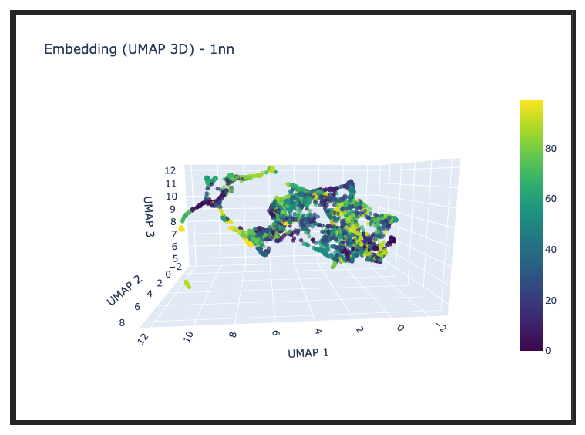

In [102]:
display_output(path="./outputs/embeddings.png")

In [69]:
viz.log_error_samples(n=20)

16:24:35 - efficient_test_100_4 - INFO - Showing 20 error samples:
16:24:35 - efficient_test_100_4 - INFO - [idx=397] true=lines1_Page_10 pred=lines2_Page_07 (author_id=9 → 72)
16:24:35 - efficient_test_100_4 - INFO - [idx=52] true=lines1_Page_02 pred=lines2_Page_03 (author_id=1 → 68)
16:24:35 - efficient_test_100_4 - INFO - [idx=2988] true=lines2_Page_03 pred=lines2_Page_11 (author_id=68 → 76)
16:24:35 - efficient_test_100_4 - INFO - [idx=860] true=lines1_Page_21 pred=lines1_Page_13 (author_id=20 → 12)
16:24:35 - efficient_test_100_4 - INFO - [idx=814] true=lines1_Page_20 pred=lines2_Page_03 (author_id=19 → 68)
16:24:35 - efficient_test_100_4 - INFO - [idx=2074] true=lines1_Page_50 pred=lines2_Page_22 (author_id=47 → 87)
16:24:35 - efficient_test_100_4 - INFO - [idx=3165] true=lines2_Page_07 pred=lines1_Page_47 (author_id=72 → 44)
16:24:35 - efficient_test_100_4 - INFO - [idx=907] true=lines1_Page_22 pred=lines2_Page_01 (author_id=21 → 66)
16:24:35 - efficient_test_100_4 - INFO - [idx

In [70]:
viz.plot_centroids()

16:24:35 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.2789 | clusters=6


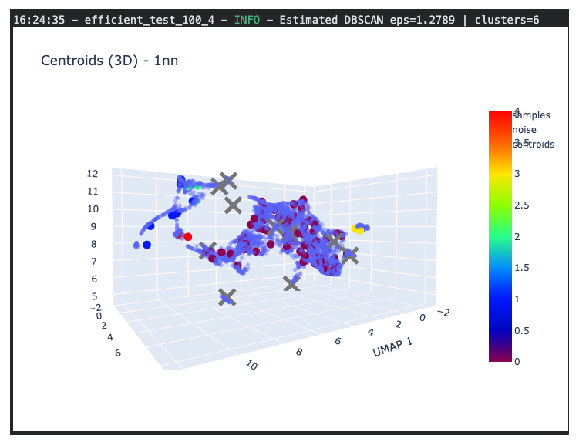

In [103]:
display_output(path="./outputs/embeddings_centroids.png")

In [71]:
one_nn = test_gen_results.strategy_results['1nn']

**Patch-level Confusion Matrix**

The patch-level confusion matrix evaluates the model’s predictions on individual image patches.

Since each patch contains only partial handwriting information, predictions at this level are inherently noisy.

This results in noticeable confusion between authors with similar local stroke patterns.

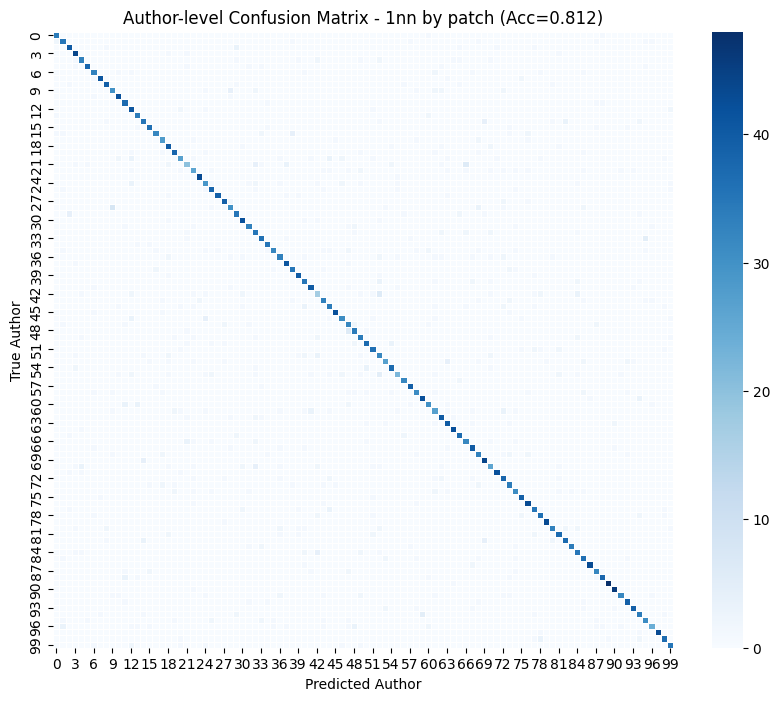

In [72]:
onenn_by_patch = one_nn['patch']
cm_df = build_author_confusion_matrix(
    onenn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by patch")

**Vote-level Confusion Matrix**

The vote-level confusion matrix represents the final classification performance after aggregating predictions across multiple patches.

By combining information from several patches, the model achieves more robust and stable predictions, significantly reducing classification errors.

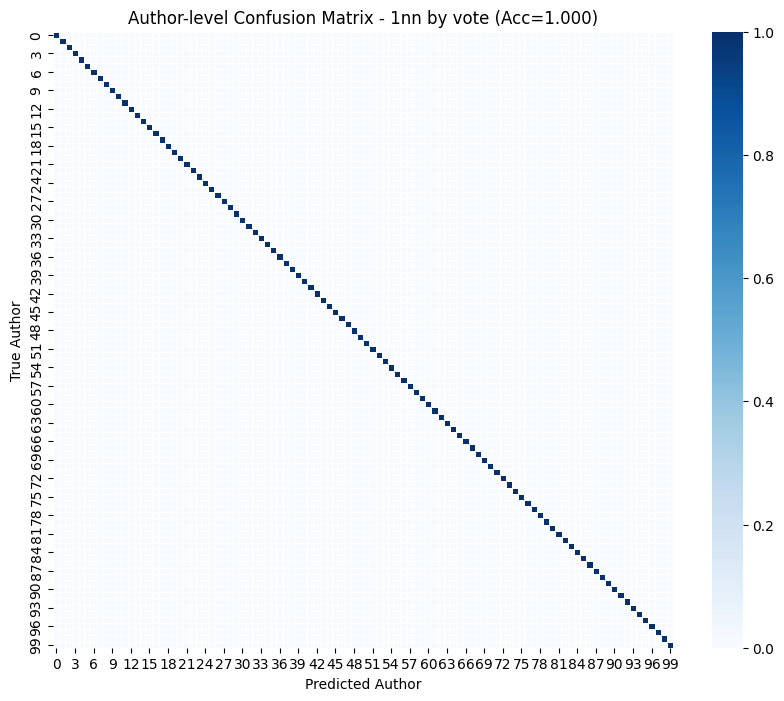

In [73]:
onenn_by_vote = one_nn['vote']
cm_df = build_author_confusion_matrix(
    onenn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by vote")

**Score-level Confusion Matrix**

The score-level aggregation selects the final prediction by accumulating cosine similarity scores across all patches per (author, author_pred) pair, choosing the candidate with the highest total similarity.

Unlike vote-level aggregation, this approach weights predictions by confidence - a small number of high-similarity patches can outweigh a larger number of low-confidence ones. This makes score particulary effective for `1nn` and `topk` strategies, where similarity is a reliable signal.

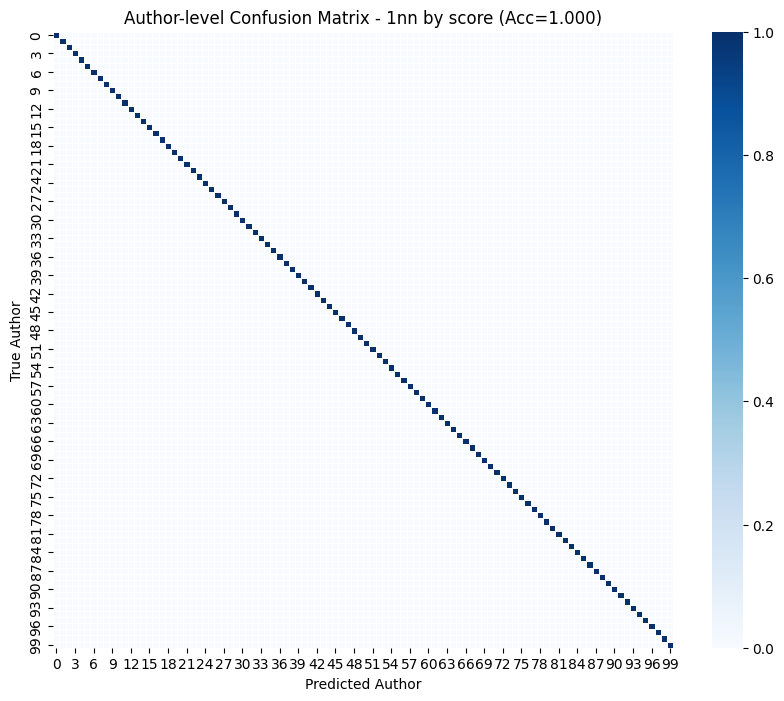

In [74]:
onenn_by_score = one_nn['score']
cm_df = build_author_confusion_matrix(
    onenn_by_score.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - 1nn by score")

**Comparison**

The comparison between patch-level, vote-level, and score-level confusion matrices highlights different aggregation strategies and their trade-offs.

At the patch level, predictions are based on individual image regions and are therefore noisy and often ambiguous.

The vote-level aggregation reduces noise by combining multiple patch predictions through majority voting, improving stability regardless of prediction confidence.

The score-level aggregation replaces frequency with accumulated cosine similarity, favoring predictions supported by high-confidence matches over predictions supported by sheer count. This leads to stronger performance in neighbor-based strategies (1nn, topk), where similarity is a direct quality measure. For representation-based strategies (mean, centroid), vote-level aggregation can be equally or more effective.

No single aggregation level dominates universally — the optimal choice depends on the strategy used.

In [75]:
viz.set_strategy("topk")

In [76]:
viz.log_error_samples(n=20)

16:41:58 - efficient_test_100_4 - INFO - Showing 20 error samples:
16:41:58 - efficient_test_100_4 - INFO - [idx=2168] true=lines1_Page_53 pred=lines1_Page_28 (author_id=50 → 27)
16:41:58 - efficient_test_100_4 - INFO - [idx=3232] true=lines2_Page_09 pred=lines1_Page_32 (author_id=74 → 31)
16:41:58 - efficient_test_100_4 - INFO - [idx=3351] true=lines2_Page_12 pred=lines1_Page_55 (author_id=77 → 52)
16:41:58 - efficient_test_100_4 - INFO - [idx=2343] true=lines1_Page_56 pred=lines1_Page_44 (author_id=53 → 41)
16:41:58 - efficient_test_100_4 - INFO - [idx=4287] true=lines2_Page_33 pred=lines2_Page_13 (author_id=98 → 78)
16:41:58 - efficient_test_100_4 - INFO - [idx=2480] true=lines1_Page_60 pred=lines2_Page_09 (author_id=57 → 74)
16:41:58 - efficient_test_100_4 - INFO - [idx=2470] true=lines1_Page_60 pred=lines1_Page_34 (author_id=57 → 33)
16:41:58 - efficient_test_100_4 - INFO - [idx=3840] true=lines2_Page_23 pred=lines1_Page_14 (author_id=88 → 13)
16:41:58 - efficient_test_100_4 - INF

In [77]:
topk = test_gen_results.strategy_results['topk']

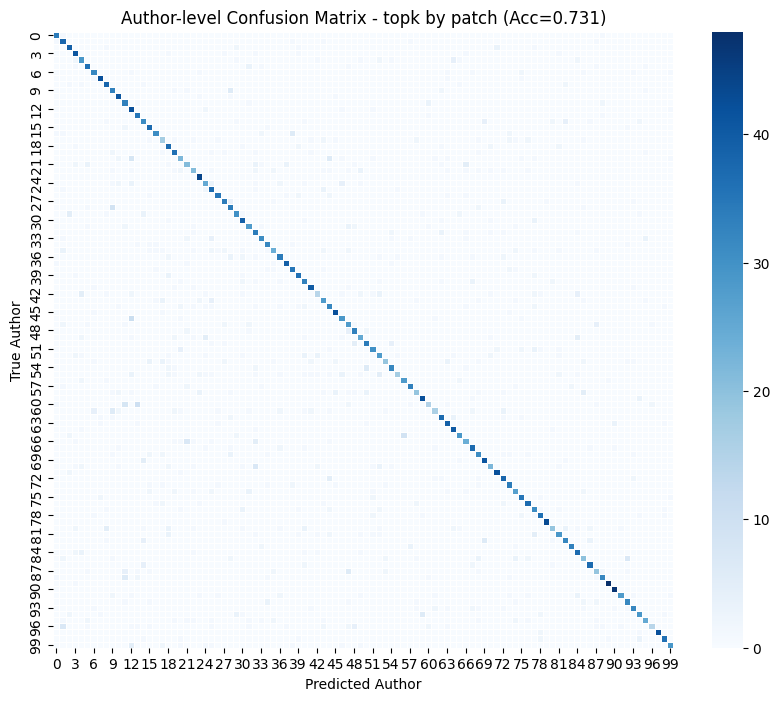

In [78]:
topk_by_patch = topk['patch']
cm_df = build_author_confusion_matrix(
    topk_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by patch")

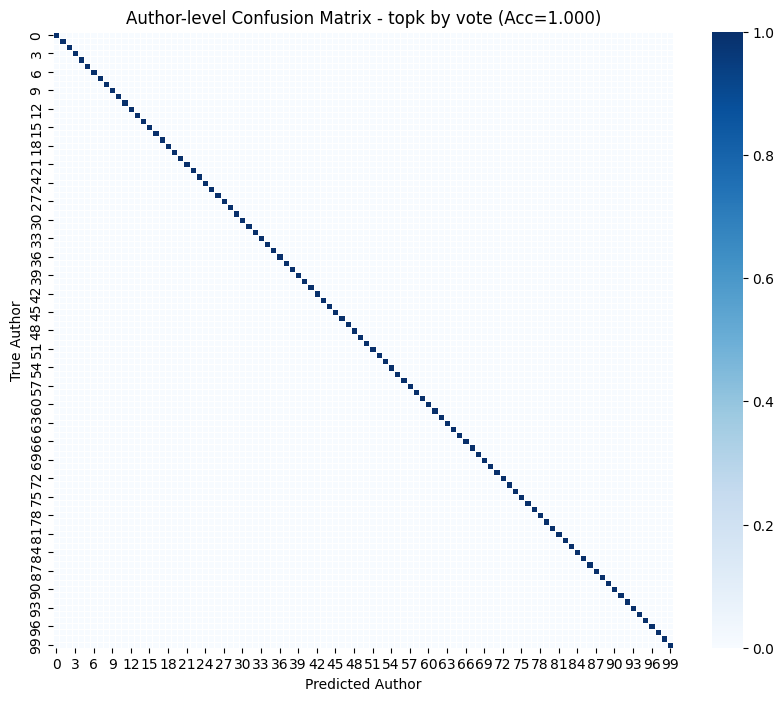

In [79]:
topk_by_vote = topk['vote']
cm_df = build_author_confusion_matrix(
    topk_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by vote")

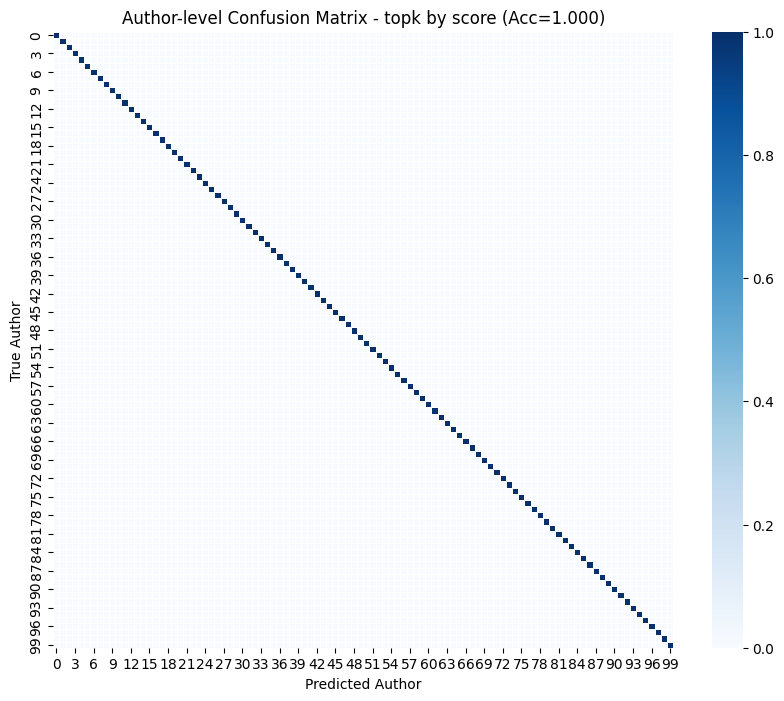

In [80]:
topk_by_score = topk['score']
cm_df = build_author_confusion_matrix(
    topk_by_score.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Author-level Confusion Matrix - topk by score")

In [81]:
viz.plot_centroids([0, 1])

16:42:20 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.2789 | clusters=6


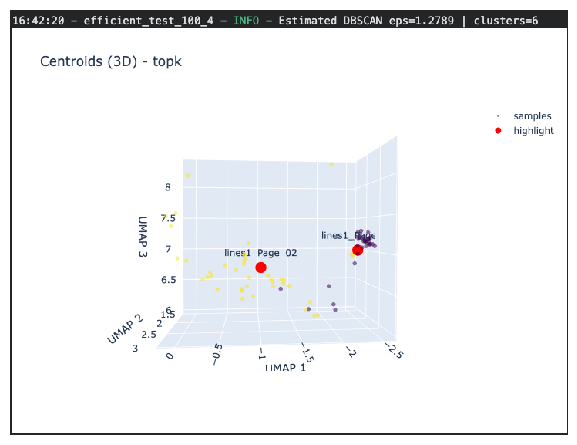

In [104]:
display_output(path="./outputs/embeddings_sample_centroids_1.png")

In [83]:
viz.plot_centroids([0, 99])

16:43:12 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.2789 | clusters=6


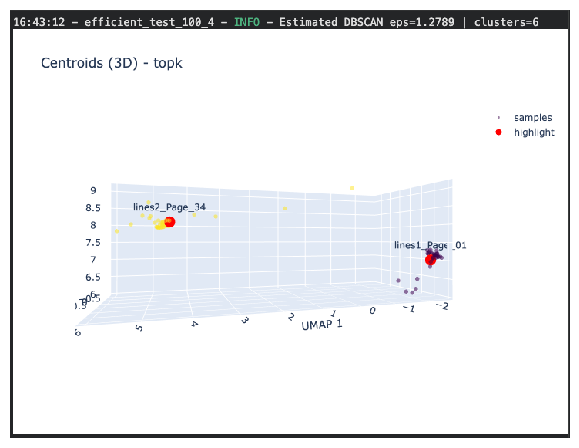

In [105]:
display_output(path="./outputs/embeddings_sample_centroids_2.png")

## Unseen Author Evaluation

So far, all evaluations have been performed on authors the model was trained on (**closed-set** evaluation).

This section evaluates the model on **completely unseen authors** — identities never seen during training.

**Why this matters:**
A metric learning model that only works on known identities has limited practical value.
True generalization means the learned embedding space transfers to new identities —
patches from the same unseen author should still cluster together, and patches from different unseen authors should remain apart.

**Setup:**
- Model trained on authors `0–99`
- Evaluated on authors `100–198` (never seen during training)
- No retraining or fine-tuning — same model, same weights

> This is the most demanding test of the system: if vote accuracy remains high on unseen authors, the model has learned a general representation of handwriting style, not a memorization of known identities.


In [84]:
unseen_train, unseen_val, unseen_test = loader.build(
    authors=range(100, 199),
    validation_fraction=config.training.val_ratio,
)

16:43:48 - efficient_test_100_4 - INFO - Total patches selected: 61448
16:43:48 - efficient_test_100_4 - INFO - Train: 46086 | Val: 15362 | Test: 4352
16:43:48 - efficient_test_100_4 - INFO - Avg non_test patches per author: 620.69 | Min: 142 | Max: 911
16:43:48 - efficient_test_100_4 - INFO - Avg test patches per author: 43.96 | Min: 22 | Max: 48
16:43:48 - efficient_test_100_4 - INFO - Image shape: (180, 360)
16:43:48 - efficient_test_100_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [85]:
unseen_test_gen = DataGenerator(
    split=unseen_test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [86]:
display_generator_info(unseen_test_gen)

16:43:51 - efficient_test_100_4 - INFO - Generator: DataGenerator
16:43:51 - efficient_test_100_4 - INFO - Number of samples: 4352
16:43:51 - efficient_test_100_4 - INFO - Batch size: 8
16:43:51 - efficient_test_100_4 - INFO - Steps per epoch: 544
16:43:51 - efficient_test_100_4 - INFO - Shape: (180, 360)
16:43:51 - efficient_test_100_4 - INFO - Number of authors: 99


In [87]:
unseen_test_gen_results = emb_evaluator.evaluate(
    data_generator=unseen_test_gen,
    reducer=UMAPReducer(n_components=3),
)

16:43:56 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Starting evaluation
16:43:56 - efficient_test_100_4 - INFO - Extracting embeddings from the model
16:43:56 - efficient_test_100_4 - INFO - Processing 544 batches to extract embeddings
16:47:37 - efficient_test_100_4 - INFO - Extracted embeddings for 4352 samples
16:47:37 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(4352, 224)
16:47:37 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances
16:47:37 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Reducing dimensionality with UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



16:47:44 - efficient_test_100_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
16:47:44 - efficient_test_100_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
16:47:44 - efficient_test_100_4 - INFO - Applying strategy: 1nn
16:47:44 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:47:44 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:47:44 - efficient_test_100_4 - INFO - Applying aggregator: score
16:47:44 - efficient_test_100_4 - INFO - patch acc=0.7592Strategy '1nn' results: , vote acc=1.0000Strategy '1nn' results: , score acc=1.0000
16:47:44 - efficient_test_100_4 - INFO - Applying strategy: mean
16:47:52 - efficient_test_100_4 - INFO - Applying aggregator: patch
16:47:52 - efficient_test_100_4 - INFO - Applying aggregator: vote
16:47:52 - efficient_test_100_4 - INFO - Applying aggregator: score
16:47:52 - efficient_test_100_4 - INFO - patch acc=0.4021Strategy 'mean' results: , vote acc=0.6162Strategy 'mean' results: , score acc

In [88]:
logger.info(f"Intra distance: {unseen_test_gen_results.intra_distance}")
logger.info(f"Inter distance: {unseen_test_gen_results.inter_distance}")

for strategy_name, agg_results in unseen_test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

16:48:05 - efficient_test_100_4 - INFO - Intra distance: 0.35101309418678284
16:48:05 - efficient_test_100_4 - INFO - Inter distance: 0.9352092742919922
16:48:05 - efficient_test_100_4 - INFO - Strategy: 1nn
16:48:05 - efficient_test_100_4 - INFO - Patch accuracy: 0.7592
16:48:05 - efficient_test_100_4 - INFO - Vote accuracy: 1.0000
16:48:05 - efficient_test_100_4 - INFO - Score accuracy: 1.0000
16:48:05 - efficient_test_100_4 - INFO - ----------------------------------------
16:48:05 - efficient_test_100_4 - INFO - Strategy: mean
16:48:05 - efficient_test_100_4 - INFO - Patch accuracy: 0.4021
16:48:05 - efficient_test_100_4 - INFO - Vote accuracy: 0.6162
16:48:05 - efficient_test_100_4 - INFO - Score accuracy: 0.6162
16:48:05 - efficient_test_100_4 - INFO - ----------------------------------------
16:48:05 - efficient_test_100_4 - INFO - Strategy: centroid
16:48:05 - efficient_test_100_4 - INFO - Patch accuracy: 0.4738
16:48:05 - efficient_test_100_4 - INFO - Vote accuracy: 0.9091
16:

## Probabilistic Interpretation of Voting

To explain the near-perfect document-level accuracy, we model the voting mechanism using a binomial distribution.

For the `unseen` setting:

$$
X \sim \text{Binomial}(n = 44, \, p = 0.7502)
$$

$$
\mu = np = 44 \cdot 0.7502 \approx 33.01
$$

$$
\sigma = \sqrt{np(1-p)} = \sqrt{44 \cdot 0.7502 \cdot 0.2498} \approx 2.87
$$

$$
P(X \ge 22) \approx P\left(Z \ge \frac{21.5 - 33.01}{2.87}\right) \approx 0.99997
$$

Thus, even for unseen authors, the probability of correct majority remains extremely high (failure probability $\approx 0.003\%$), which is consistent with the observed vote accuracy of 1.0 and score accuracy of 1.0.

---

Additionally, the embedding space maintains strong separability in the unseen setting:

$$
\text{Intra distance} \approx 0.351, \quad
\text{Inter distance} \approx 0.9352, \quad
\frac{\text{Inter}}{\text{Intra}} \approx 2.66
$$

This large margin between intra-class and inter-class distances (ratio of 2.66) supports robust nearest-neighbor decisions, even for authors the model has never encountered during training.

---

However, this analysis assumes independence between patches. In practice, patches extracted from the same document are correlated (e.g., same pen, paper, or writing conditions).

Nevertheless, since $p \gg 0.5$ ($75\%$ vs the $50\%$ required for a majority), the majority vote remains highly reliable even under moderate correlation, as the expected mean ($\mu \approx 33$) is nearly 4 standard deviations away from the decision threshold (22).

### Unseen Results Summary

The drop in patch accuracy (~5pp) is expected — the model was not trained on these identities.
The fact that **vote accuracy remains 100%** confirms that the embedding space generalizes:
individual patch ambiguity is resolved by aggregation, even for completely new authors.


In [89]:
unseen_viz = EmbeddingVisualizer(
    report=unseen_test_gen_results,
    logger=logger,
    split=unseen_test,
)
unseen_viz.set_strategy("1nn")

In [90]:
unseen_viz.plot_embeddings()

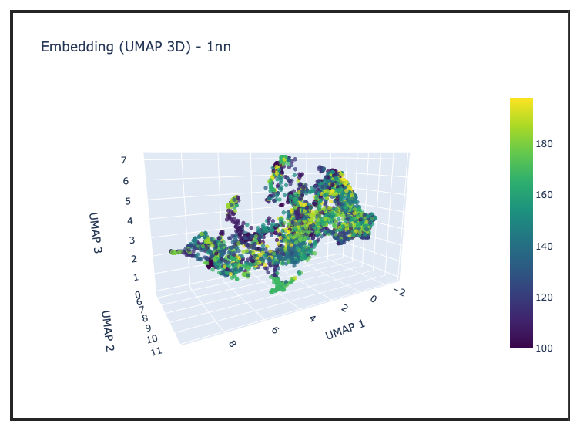

In [106]:
display_output(path="./outputs/unseen_embeddings.png")

In [91]:
unseen_viz.plot_centroids()

16:48:05 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.0135 | clusters=9


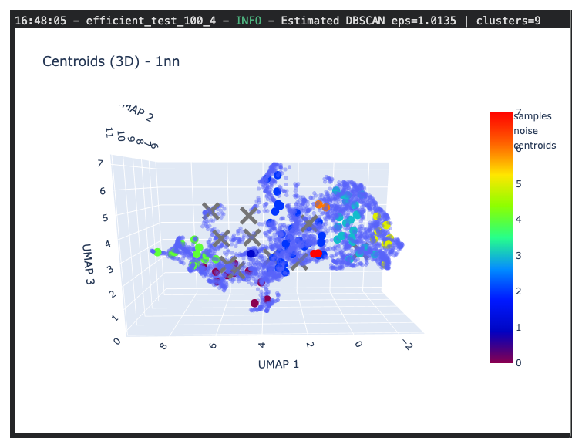

In [107]:
display_output(path="./outputs/unseen_embeddings_centroids.png")

In [92]:
unseen_1nn = unseen_test_gen_results.strategy_results['1nn']

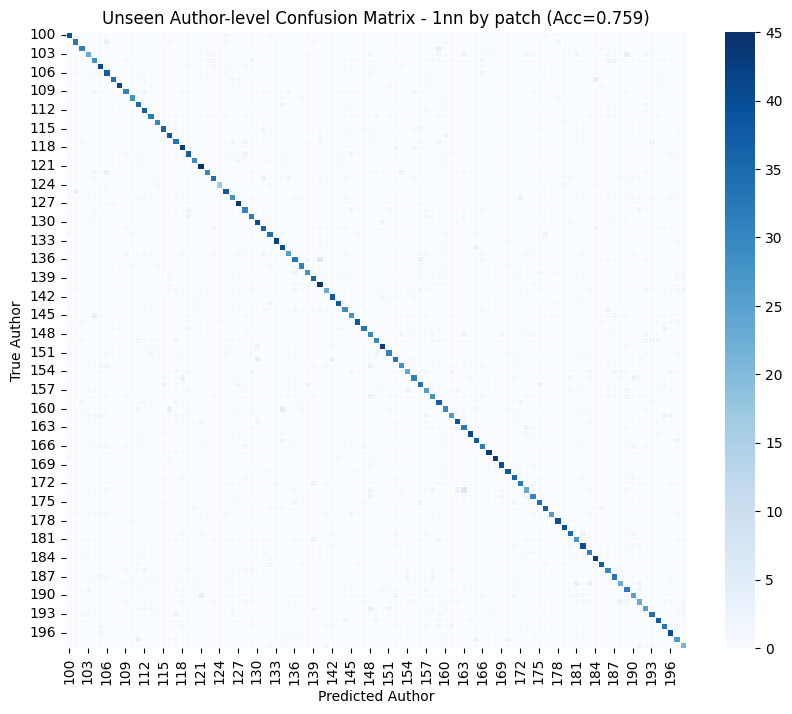

In [93]:
unseen_1nn_by_patch = unseen_1nn['patch']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_patch.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by patch")

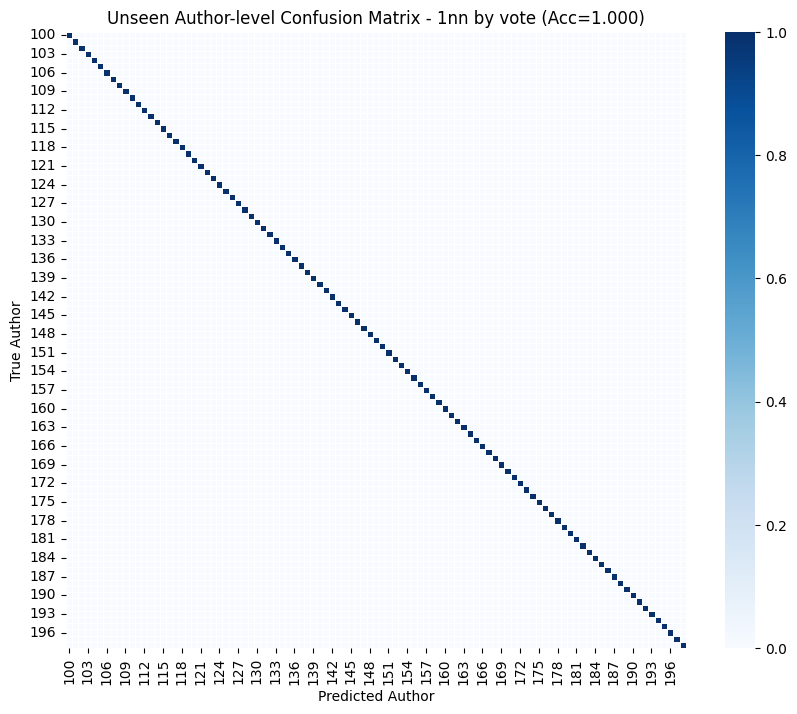

In [94]:
unseen_1nn_by_vote = unseen_1nn['vote']
cm_df = build_author_confusion_matrix(
    unseen_1nn_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - 1nn by vote")

In [95]:
unseen_viz.set_strategy("centroid")
unseen_centroid = unseen_test_gen_results.strategy_results['centroid']

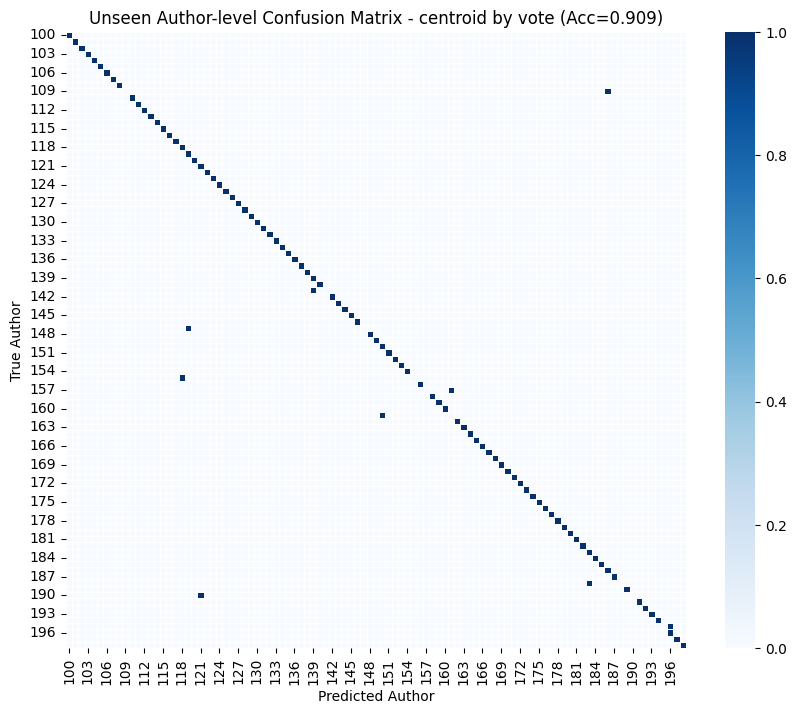

In [96]:
unseen_centroid_by_vote = unseen_centroid['vote']
cm_df = build_author_confusion_matrix(
    unseen_centroid_by_vote.data,
    true_col="author",
    pred_col="author_pred"
)
display_heatmap(cm_df, title="Unseen Author-level Confusion Matrix - centroid by vote")

In [100]:
unseen_viz.plot_centroids([100, 198])

17:31:05 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.0135 | clusters=9


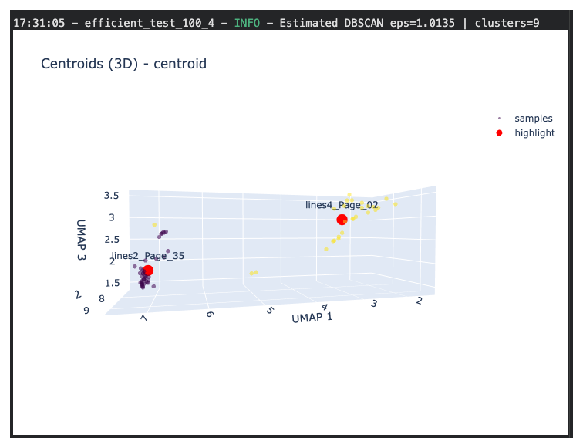

In [110]:
display_output(path="./outputs/unseen_embeddings_sample_1.png")

In [97]:
centroid_data = unseen_centroid_by_vote.data
centroid_error_data = centroid_data[centroid_data['correct'] == False]
centroid_error_data[['author', 'author_pred']]

,author,author_pred
9,109,186
41,141,139
47,147,119
55,155,118
57,157,161
61,161,150
88,188,183
90,190,121
95,195,196


### Error Analysis — Unseen Authors

The following pairs are the authors misclassified by the centroid strategy.
Each pair is visualized in UMAP space to understand why the model confuses them.

These errors are particularly informative in the unseen setting:
since the model never saw these authors, confusions reveal genuine similarity
in handwriting style rather than artifacts of training.

In [98]:
unseen_viz.plot_centroids([109, 186])

17:05:02 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.0135 | clusters=9


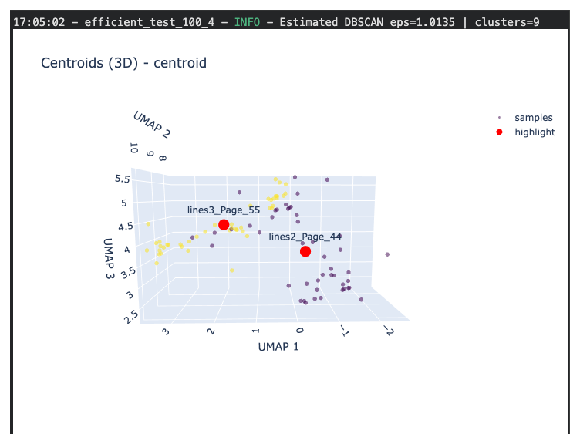

In [108]:
display_output(path="./outputs/unseen_embeddings_sample_errors_1.png")

In [99]:
unseen_viz.plot_centroids([141, 139])

17:05:31 - efficient_test_100_4 - INFO - Estimated DBSCAN eps=1.0135 | clusters=9


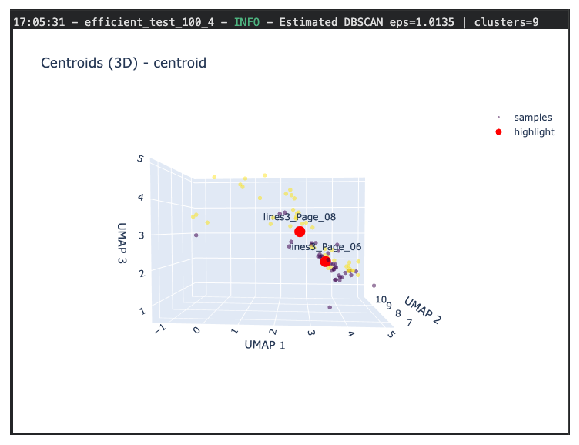

In [109]:
display_output(path="./outputs/unseen_embeddings_sample_errors_2.png")